In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Instagram_Analytics.csv')



In [2]:
# print("First 5 rows of the dataset:")
# print(df.head())

print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  str    
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  str    
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  str    
 5   content_category          29999 non-null  str    
 6   traffic_source            29999 non-null  str    
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  str    
 9   post_date                 29999 non-null  str    
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  str    
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  sha

In [3]:
df.performance_bucket_label  

0        medium
1         viral
2          high
3        medium
4           low
          ...  
29994       low
29995       low
29996      high
29997    medium
29998       low
Name: performance_bucket_label, Length: 29999, dtype: str

In [7]:
df.isnull().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

In [8]:
# uselessColumns
to_drop = ['post_id', 'account_id', 'post_datetime', 'post_date']
#Must drop so that the model doesnt learn from them and overfit
leakage_columns = ['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained']


df = df.drop(columns= to_drop + leakage_columns)

print(df.columns)

Index(['account_type', 'follower_count', 'media_type', 'content_category',
       'traffic_source', 'has_call_to_action', 'post_hour', 'day_of_week',
       'caption_length', 'hashtags_count', 'performance_bucket_label'],
      dtype='str')


OutLierS

<Axes: xlabel='follower_count'>

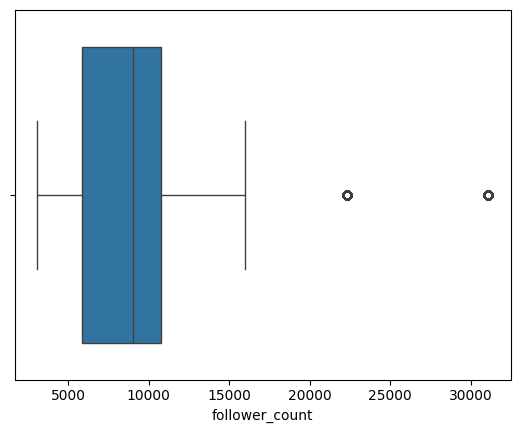

In [9]:
sns.boxplot(x=df['follower_count'])

<Axes: xlabel='caption_length'>

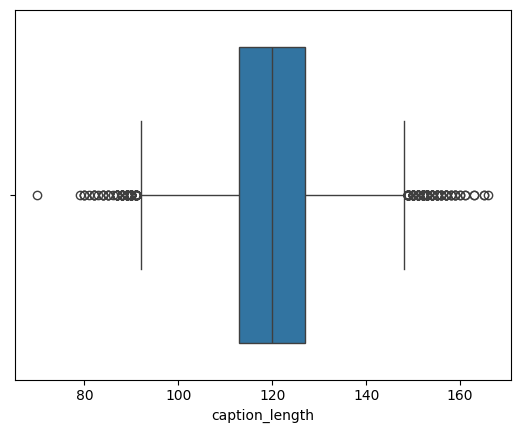

In [10]:
sns.boxplot(x=df['caption_length'])

<Axes: xlabel='hashtags_count'>

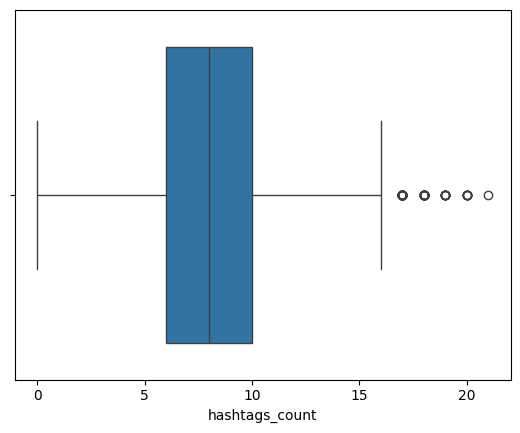

In [11]:
sns.boxplot(x=df['hashtags_count'])

In [12]:
numeric_cols = ['follower_count', 'caption_length', 'hashtags_count']


for col in numeric_cols:
    Q1 = df[col].quantile(0.25) # الربع الأول
    Q3 = df[col].quantile(0.75) # الربع الثالث
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled ")

Outliers handled 


Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

#OneHOt for non-ordinal categorical features
categorical_cols = ['account_type', 'media_type', 'content_category', 'traffic_source', 'day_of_week']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
#Label for OrdInal
le = LabelEncoder()
df['performance_bucket_label'] = le.fit_transform(df['performance_bucket_label'])



In [14]:
df.columns

Index(['follower_count', 'has_call_to_action', 'post_hour', 'caption_length',
       'hashtags_count', 'performance_bucket_label', 'account_type_creator',
       'media_type_image', 'media_type_reel', 'content_category_Comedy',
       'content_category_Fashion', 'content_category_Fitness',
       'content_category_Food', 'content_category_Lifestyle',
       'content_category_Music', 'content_category_Photography',
       'content_category_Technology', 'content_category_Travel',
       'traffic_source_External', 'traffic_source_Hashtags',
       'traffic_source_Home Feed', 'traffic_source_Profile',
       'traffic_source_Reels Feed', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday',
       'day_of_week_Tuesday', 'day_of_week_Wednesday'],
      dtype='str')

Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ['follower_count', 'post_hour', 'caption_length', 'hashtags_count']


df[numeric_features] = scaler.fit_transform(df[numeric_features])

# 4. عرض أول صفوف بعد التعديل
print(df[numeric_features].head())

   follower_count  post_hour  caption_length  hashtags_count
0       -1.262195  -0.796962       -1.842405       -0.349594
1        1.860770   0.507296        0.177232       -1.061527
2       -0.272146   0.652214       -0.465380        0.006372
3       -0.084045  -1.231715       -0.465380       -0.349594
4        1.404889  -0.362210       -0.740785        0.362338


SPliiting Data

In [16]:
from sklearn.model_selection import train_test_split


X = df.drop('performance_bucket_label', axis=1)
y = df['performance_bucket_label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Splitting Completed Successfully!")

Data Splitting Completed Successfully!


In [17]:
# هل يوجد أي قيم مفقودة؟ (يجب أن يكون الناتج 0)
print(X_train.isnull().sum().sum())

# هل كل الأعمدة أرقام؟ (يجب أن يكون الناتج True)
print(all(X_train.dtypes != 'object'))

0
True
